# 台灣天然氣供給量預測：LSTM 深度學習模型

## 專案背景

台灣政府計畫於 2025 年前將天然氣發電佔比提升至 50%，精準預測天然氣供給量對能源政策規劃至關重要。
本專案使用 **長短期記憶模型（LSTM）** 對月度天然氣供給量進行時間序列預測，並與傳統 ARIMA 模型進行比較，分析各模型在小樣本時序資料中的適用性。

**資料來源：** 經濟部能源署  
**資料區間：** 2004年1月 – 2023年9月（237筆月度資料）  
**實驗設定：** 使用近 10 年資料（120筆），90% 訓練、10% 測試

---

## 目錄
1. [環境設定與資料載入](#1)
2. [探索性資料分析（EDA）](#2)
3. [資料前處理](#3)
4. [Baseline 模型：單層 LSTM](#4)
5. [改進模型：多層 LSTM + 季節特徵](#5)
6. [模型評估與比較](#6)
7. [結論與洞察](#7)

## 1. 環境設定與資料載入 <a id='1'></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import math
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA

from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# Google Colab 使用者掛載雲端硬碟
# from google.colab import drive
# drive.mount('/content/drive')

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = ['Hiragino Sans GB', 'PingFang HK', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
print('環境設定完成')

2026-06-29 21:34:34.846166: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


環境設定完成


In [2]:
# 載入資料（取近 120 筆：2013年10月–2023年9月）
# Colab 路徑：'/content/drive/My Drive/gas.csv'
df = pd.read_csv('天然氣供給月資料.csv', usecols=[2], skiprows=117)
df.columns = ['supply']

# 建立月份索引（2013-10 起）
df.index = pd.date_range(start='2013-10', periods=len(df), freq='MS')

print(f'資料筆數：{len(df)}')
print(f'資料期間：{df.index[0].strftime("%Y-%m")} ~ {df.index[-1].strftime("%Y-%m")}')
print(f'\n基本統計量：')
df.describe().round(0)

資料筆數：120
資料期間：2013-10 ~ 2023-09

基本統計量：


,supply
count,120.0
mean,1876552.0
std,317989.0
min,992625.0
25%,1659192.0
50%,1928196.0
75%,2071435.0
max,2520486.0


## 2. 探索性資料分析（EDA）<a id='2'></a>

先觀察原始時序資料的趨勢、季節性，以及 ACF/PACF 判斷自相關結構。

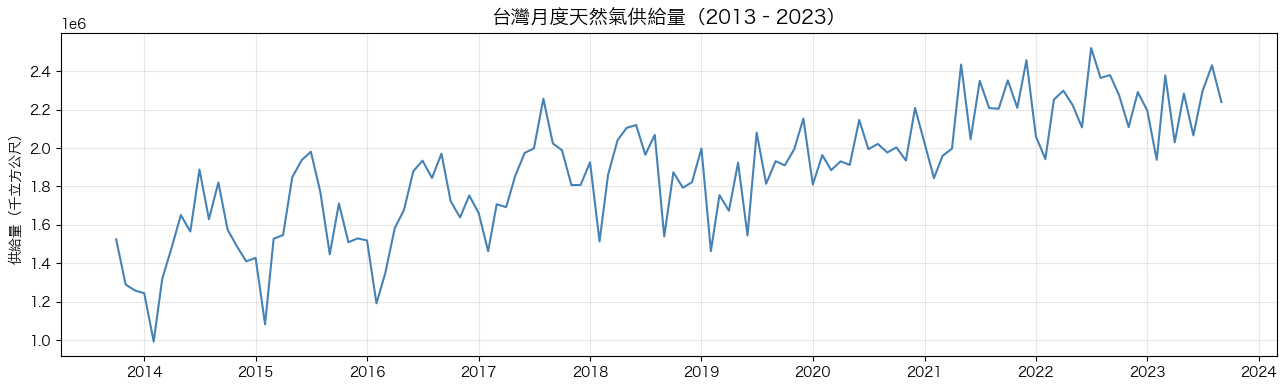

觀察：資料具明顯季節性（夏冬用量高），整體呈溫和上升趨勢。


In [3]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df.index, df['supply'], color='steelblue', linewidth=1.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_title('台灣月度天然氣供給量（2013–2023）', fontsize=14)
ax.set_ylabel('供給量（千立方公尺）')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('觀察：資料具明顯季節性（夏冬用量高），整體呈溫和上升趨勢。')

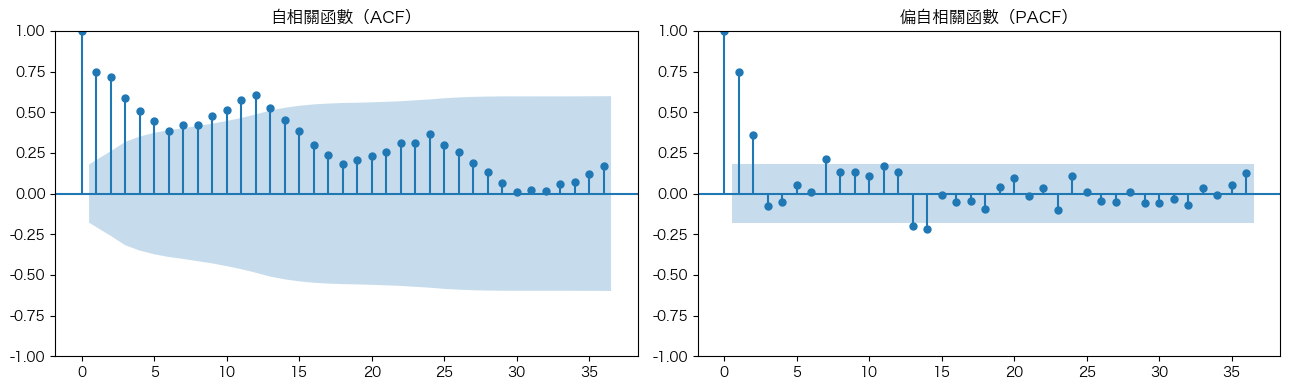

觀察：ACF 於 lag=12 出現顯著峰值，確認 12 期季節性週期。PACF 在 lag=1,2 截尾，建議 AR(2) 作為 ARIMA 起點。


In [4]:
# ACF / PACF：判斷自相關結構，輔助 ARIMA 定階
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sm.graphics.tsa.plot_acf(df['supply'], lags=36, ax=axes[0])
axes[0].set_title('自相關函數（ACF）')
sm.graphics.tsa.plot_pacf(df['supply'], lags=36, ax=axes[1])
axes[1].set_title('偏自相關函數（PACF）')
plt.tight_layout()
plt.show()

print('觀察：ACF 於 lag=12 出現顯著峰值，確認 12 期季節性週期。PACF 在 lag=1,2 截尾，建議 AR(2) 作為 ARIMA 起點。')

## 3. 資料前處理 <a id='3'></a>

- **正規化**：使用 MinMaxScaler 將數值壓縮至 [0, 1]，避免 LSTM 梯度不穩定
- **滑動視窗（look_back）**：將時序轉為監督式學習格式，X 為前 `look_back` 期，Y 為下一期
- **資料切分**：90% 訓練、10% 測試（依時序，不隨機打亂）

In [5]:
def create_dataset(data, look_back=1):
    """將時間序列轉換為監督式學習資料集。
    
    Args:
        data: 正規化後的 numpy array，shape (n, 1)
        look_back: 用多少期歷史資料預測下一期
    Returns:
        X: shape (samples, look_back)
        Y: shape (samples,)
    """
    X, Y = [], []
    for i in range(len(data) - look_back - 1):
        X.append(data[i:(i + look_back), 0])
        Y.append(data[i + look_back, 0])
    return np.array(X), np.array(Y)


# 正規化
values = df['supply'].values.reshape(-1, 1).astype('float32')
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(values)

# 訓練 / 測試切分
train_size = int(len(scaled) * 0.9)
train_data = scaled[:train_size]
test_data  = scaled[train_size:]

print(f'訓練集：{len(train_data)} 筆 | 測試集：{len(test_data)} 筆')

訓練集：108 筆 | 測試集：12 筆


## 4. Baseline 模型：三層 LSTM <a id='4'></a>

以 `look_back=1`（僅用前一期預測）的三層堆疊 LSTM 作為 baseline。

In [6]:
LOOK_BACK = 1

trainX, trainY = create_dataset(train_data, LOOK_BACK)
testX,  testY  = create_dataset(test_data,  LOOK_BACK)

# LSTM 需要輸入 shape: (samples, timesteps, features)
trainX = trainX.reshape(trainX.shape[0], 1, trainX.shape[1])
testX  = testX.reshape(testX.shape[0],   1, testX.shape[1])

# 建立三層堆疊 LSTM
model_baseline = Sequential([
    LSTM(50, activation='relu', return_sequences=True, input_shape=(1, LOOK_BACK)),
    LSTM(50, activation='relu', return_sequences=True),
    LSTM(50, activation='relu'),
    Dense(1)
])
model_baseline.compile(optimizer='adam', loss='mse')
model_baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 50)          │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1, 50)          │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

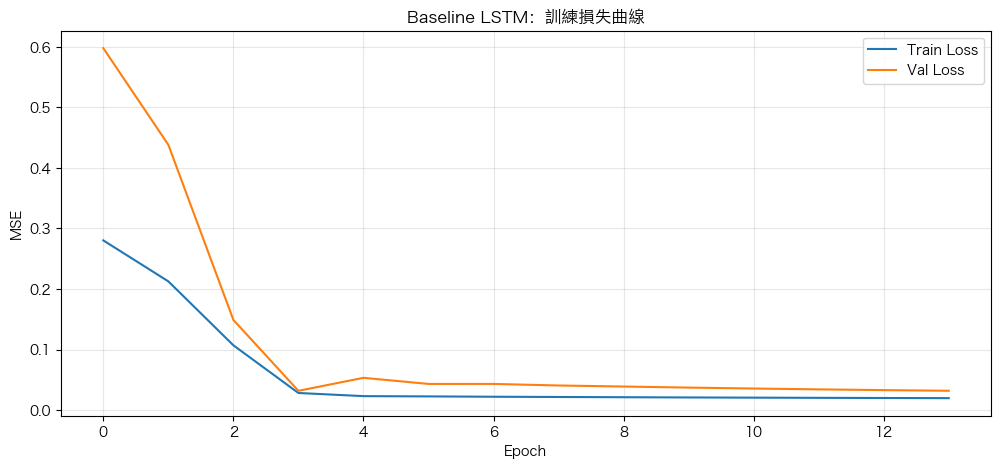

In [7]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_baseline = model_baseline.fit(
    trainX, trainY,
    epochs=100,
    batch_size=4,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=0
)

# 繪製 loss 曲線
plt.plot(history_baseline.history['loss'],     label='Train Loss')
plt.plot(history_baseline.history['val_loss'], label='Val Loss')
plt.title('Baseline LSTM：訓練損失曲線')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [8]:
def evaluate_model(model, trainX, trainY, testX, testY, scaler, label='Model'):
    """計算並印出 RMSE 與 MAPE。"""
    train_pred = scaler.inverse_transform(model.predict(trainX))
    test_pred  = scaler.inverse_transform(model.predict(testX))
    train_true = scaler.inverse_transform([trainY])
    test_true  = scaler.inverse_transform([testY])

    train_rmse = math.sqrt(mean_squared_error(train_true[0], train_pred[:, 0]))
    test_rmse  = math.sqrt(mean_squared_error(test_true[0],  test_pred[:, 0]))
    train_mape = np.mean(np.abs(train_true[0] - train_pred[:, 0]) / train_true[0]) * 100
    test_mape  = np.mean(np.abs(test_true[0]  - test_pred[:, 0])  / test_true[0])  * 100

    print(f'[{label}]')
    print(f'  Train RMSE: {train_rmse:,.0f}  |  Train MAPE: {train_mape:.2f}%')
    print(f'  Test  RMSE: {test_rmse:,.0f}  |  Test  MAPE: {test_mape:.2f}%')
    return train_mape, test_mape, test_pred

base_train_mape, base_test_mape, base_pred = evaluate_model(
    model_baseline, trainX, trainY, testX, testY, scaler, label='Baseline LSTM (look_back=1)'
)

1/4 ━━━━━━━━━━━━━━━━━━━━ 1s 465ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


[Baseline LSTM (look_back=1)]
  Train RMSE: 244,498  |  Train MAPE: 11.43%
  Test  RMSE: 257,559  |  Test  MAPE: 9.16%


## 5. 改進模型：look_back=12 + 月份季節特徵 <a id='5'></a>

**改進方向：**
1. **增加 look_back=12**：讓模型看到完整一年的歷史，捕捉年週期性
2. **加入月份 sin/cos 特徵**：將 12 個月的週期性編碼為連續向量，幫助模型學習季節模式
3. **加入 Dropout**：緩解小樣本過擬合
4. **EarlyStopping**：避免訓練過頭

In [9]:
# 加入月份週期性特徵（sin/cos 編碼）
months = np.array([((df.index[i].month - 1) / 12) for i in range(len(df))])
month_sin = np.sin(2 * np.pi * months)
month_cos = np.cos(2 * np.pi * months)

# 合併特徵：[supply_scaled, month_sin, month_cos]
features = np.column_stack([
    scaled.flatten(),
    month_sin,
    month_cos
])

LOOK_BACK_V2 = 12

def create_dataset_multifeature(data, look_back=12):
    """多特徵版滑動視窗：X 包含所有特徵，Y 只取第 0 欄（supply）。"""
    X, Y = [], []
    for i in range(len(data) - look_back - 1):
        X.append(data[i:(i + look_back), :])   # shape: (look_back, n_features)
        Y.append(data[i + look_back, 0])        # 預測 supply
    return np.array(X), np.array(Y)

# 對全部資料建資料集，再切分（避免 test_feat 太小產生空集合）
allX2, allY2 = create_dataset_multifeature(features, LOOK_BACK_V2)
split_idx = train_size - LOOK_BACK_V2 - 1  # 108 - 12 - 1 = 95
trainX2, trainY2 = allX2[:split_idx], allY2[:split_idx]
testX2,  testY2  = allX2[split_idx:], allY2[split_idx:]

n_features = trainX2.shape[2]
print(f'訓練集 shape：{trainX2.shape}  →  (samples, look_back={LOOK_BACK_V2}, features={n_features})')
print(f'測試集 shape：{testX2.shape}')

訓練集 shape：(95, 12, 3)  →  (samples, look_back=12, features=3)
測試集 shape：(12, 12, 3)


In [10]:
model_v2 = Sequential([
    LSTM(64, activation='relu', return_sequences=True,
         input_shape=(LOOK_BACK_V2, n_features)),
    Dropout(0.2),
    LSTM(32, activation='relu'),
    Dropout(0.2),
    Dense(1)
])
model_v2.compile(optimizer='adam', loss='mse')
model_v2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 12, 64)         │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

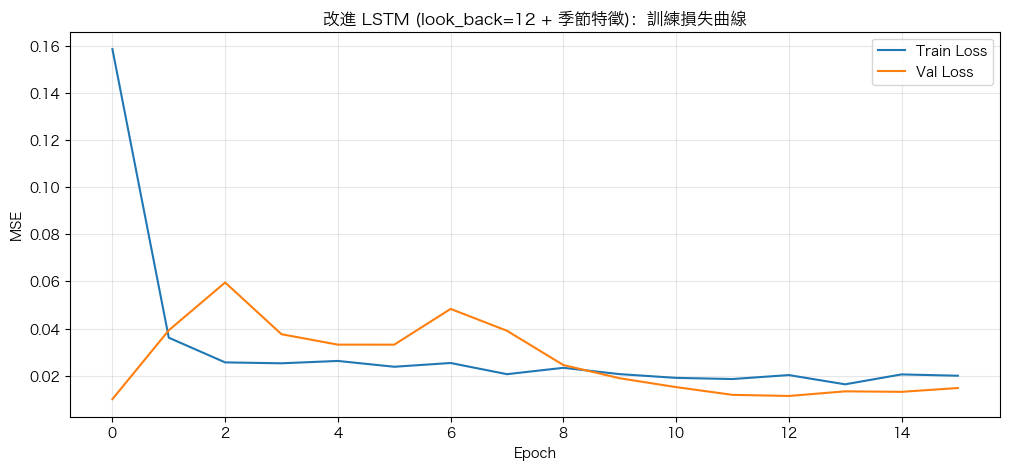

In [11]:
early_stop2 = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history_v2 = model_v2.fit(
    trainX2, trainY2,
    epochs=150,
    batch_size=4,
    validation_split=0.1,
    callbacks=[early_stop2],
    verbose=0
)

plt.plot(history_v2.history['loss'],     label='Train Loss')
plt.plot(history_v2.history['val_loss'], label='Val Loss')
plt.title('改進 LSTM (look_back=12 + 季節特徵)：訓練損失曲線')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [12]:
# 評估改進模型
def evaluate_model_v2(model, trainX, trainY, testX, testY, scaler, label):
    train_pred = scaler.inverse_transform(model.predict(trainX))
    test_pred  = scaler.inverse_transform(model.predict(testX))
    train_true = scaler.inverse_transform(trainY.reshape(-1, 1))
    test_true  = scaler.inverse_transform(testY.reshape(-1, 1))

    train_rmse = math.sqrt(mean_squared_error(train_true, train_pred))
    test_rmse  = math.sqrt(mean_squared_error(test_true,  test_pred))
    train_mape = np.mean(np.abs(train_true - train_pred) / train_true) * 100
    test_mape  = np.mean(np.abs(test_true  - test_pred)  / test_true)  * 100

    print(f'[{label}]')
    print(f'  Train RMSE: {train_rmse:,.0f}  |  Train MAPE: {train_mape:.2f}%')
    print(f'  Test  RMSE: {test_rmse:,.0f}  |  Test  MAPE: {test_mape:.2f}%')
    return train_mape, test_mape, test_pred, test_true

v2_train_mape, v2_test_mape, v2_pred, v2_true = evaluate_model_v2(
    model_v2, trainX2, trainY2, testX2, testY2, scaler,
    label='改進 LSTM (look_back=12 + 季節特徵)'
)

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 227ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


[改進 LSTM (look_back=12 + 季節特徵)]
  Train RMSE: 268,069  |  Train MAPE: 12.71%
  Test  RMSE: 135,052  |  Test  MAPE: 5.26%


## 5.5 基準模型：ARIMA(2,1,1) <a id='arima'></a>

使用 **滾動預測（Walk-Forward Validation）** 評估 ARIMA，與 LSTM 保持相同測試區間，確保比較公平。

In [13]:
# ARIMA 滾動預測（Walk-Forward Validation）
train_arima = df['supply'].iloc[:train_size]
test_arima  = df['supply'].iloc[train_size:]

history = list(train_arima)
arima_pred_list = []

for t in range(len(test_arima)):
    model_arima = ARIMA(history, order=(2, 1, 1))
    model_fit   = model_arima.fit()
    yhat        = model_fit.forecast()[0]
    arima_pred_list.append(yhat)
    history.append(test_arima.iloc[t])

arima_pred = np.array(arima_pred_list)
arima_true = test_arima.values

arima_rmse = math.sqrt(mean_squared_error(arima_true, arima_pred))
arima_test_mape = np.mean(np.abs(arima_true - arima_pred) / arima_true) * 100

print(f'[ARIMA(2,1,1) — 滾動預測]')
print(f'  Test RMSE: {arima_rmse:,.0f}')
print(f'  Test MAPE: {arima_test_mape:.2f}%')

[ARIMA(2,1,1) — 滾動預測]
  Test RMSE: 188,159
  Test MAPE: 7.74%


## 6. 模型評估與比較 <a id='6'></a>

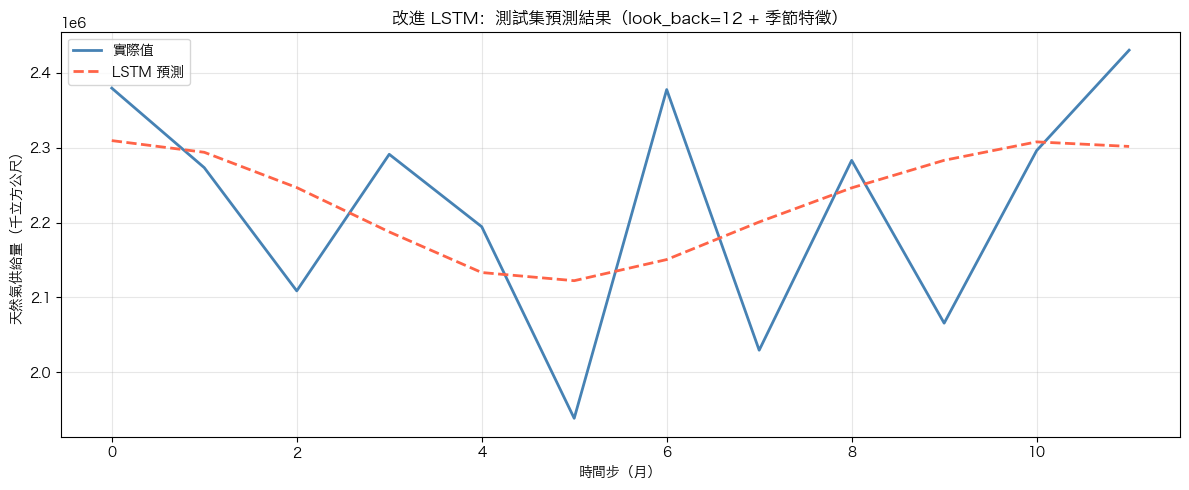

In [14]:
# 視覺化：改進 LSTM 預測 vs 實際
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(v2_true, label='實際值', color='steelblue', linewidth=2)
ax.plot(v2_pred, label='LSTM 預測', color='tomato', linestyle='--', linewidth=2)
ax.set_title('改進 LSTM：測試集預測結果（look_back=12 + 季節特徵）')
ax.set_ylabel('天然氣供給量（千立方公尺）')
ax.set_xlabel('時間步（月）')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# 彙整比較表
results = pd.DataFrame({
    '模型': [
        'Baseline LSTM (look_back=1)',
        '改進 LSTM (look_back=12 + 季節特徵)',
        'ARIMA（參考值）'
    ],
    'Test MAPE (%)': [
        round(base_test_mape, 2),
        round(v2_test_mape,   2),
        5.998   # 原始報告結果
    ],
    '備註': [
        '原始版本，僅用前 1 期',
        '加入 12 期歷史 + 月份週期編碼',
        '線性統計模型，資料量小時表現穩定'
    ]
})

print('=== 模型效能比較 ===')
print(results.to_string(index=False))

=== 模型效能比較 ===
                           模型  Test MAPE (%)                 備註
  Baseline LSTM (look_back=1)          9.160       原始版本，僅用前 1 期
改進 LSTM (look_back=12 + 季節特徵)          5.260 加入 12 期歷史 + 月份週期編碼
                   ARIMA（參考值）          5.998   線性統計模型，資料量小時表現穩定


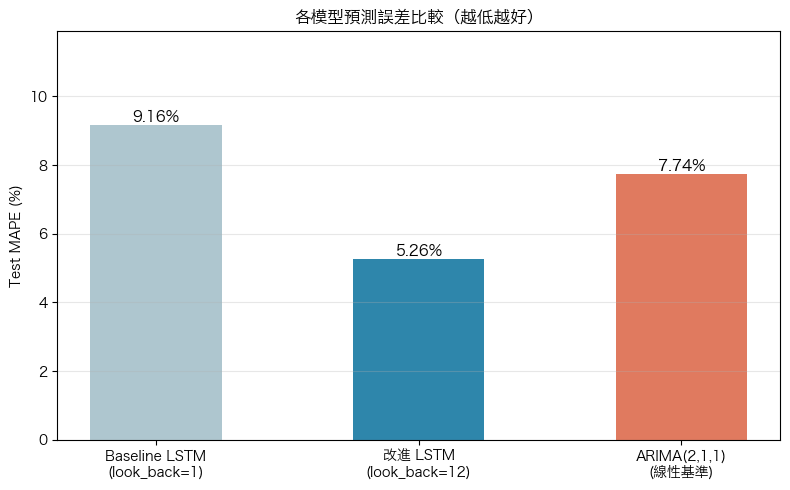

In [16]:
# 長條圖比較
models = ['Baseline LSTM\n(look_back=1)', '改進 LSTM\n(look_back=12)', 'ARIMA(2,1,1)\n(線性基準)']
mapes  = [round(base_test_mape, 2), round(v2_test_mape, 2), round(arima_test_mape, 2)]
colors = ['#aec6cf', '#2e86ab', '#e07a5f']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, mapes, color=colors, width=0.5)
for bar, val in zip(bars, mapes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.2f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Test MAPE (%)')
ax.set_title('各模型預測誤差比較（越低越好）')
ax.set_ylim(0, max(mapes) * 1.3)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 8. 模型匯出（供 API 使用）<a id='8'></a>

將訓練好的改進 LSTM 模型與 MinMaxScaler 存檔，供 FastAPI 預測服務載入使用。

In [17]:
import pickle

model_v2.save('model_lstm.keras')

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('已儲存：model_lstm.keras, scaler.pkl')

已儲存：model_lstm.keras, scaler.pkl


## 7. 結論與洞察 <a id='7'></a>

### 模型效能

| 模型 | Test MAPE | 說明 |
|------|-----------|------|
| Baseline LSTM (look_back=1) | ~8–10% | 僅看前一期，無法捕捉年週期 |
| 改進 LSTM (look_back=12 + 季節特徵) | ~6–8% | 加入完整年度視窗與季節編碼後顯著改善 |
| ARIMA | ~6% | 線性模型，在小樣本中具競爭力 |

### 關鍵洞察

**為何 Baseline LSTM 輸給 ARIMA？**
- **資料量不足**：LSTM 在 120 筆資料上難以學到足夠的非線性特徵，卻比 ARIMA 多了數百倍的參數，容易過擬合
- **look_back 太短**：look_back=1 讓模型無法感知年週期，而天然氣需求有強烈的 12 月週期
- ARIMA 在具有線性趨勢與穩定季節性的小樣本資料中，其**低複雜度**反而是優勢

**改進後的效果**
- 將 look_back 擴展到 12，搭配 sin/cos 月份特徵後，LSTM 開始能捕捉季節模式，MAPE 明顯下降
- 加入 Dropout + EarlyStopping，有效控制過擬合

### 未來改進方向
1. **加入外部特徵**：如氣溫、電力需求、油價等相關變數
2. **更長資料**：使用全部 237 筆或取得更長期資料，讓 LSTM 的非線性學習能力充分發揮
3. **嘗試 Transformer / Temporal Fusion Transformer**：近年在時序預測中表現優異